<a href="https://colab.research.google.com/github/Matheus-Santos-AI/FarmTech-na-Era-da-Cloud-Computing/blob/main/Cap_1_FarmTech_na_Era_da_Cloud_Computing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Integrantes:
- Matheus de S. Santos Rm566901
- Ricardo José Amorin Rm567312
- Klaus Lohany Barbosa de Oliveira
- Victor Oliveira Fedeli Tate Rm566823
- Paulo Roberto Silva Amaral Ribeiro Junior Rm568413

BIBLIOTECAS

In [3]:
# Instalações
!pip install pycaret
!pip install lime
!pip install shap
# Apenas para evitar warnings
import warnings
warnings.filterwarnings('ignore')
from pycaret.regression import*
# Bibliotecas de Data Science
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
# Separação dos dados
from sklearn.model_selection import train_test_split
# Modelos a serem utilizados
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
# Avaliação de modelos
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from lime import lime_tabular
import shap

In [4]:
#importação de dados do arquivo csv
data = pd.read_csv('crop_yield.csv')
data_predict = data

##ANALISE DOS DADOS

In [5]:
#   - Informações gerais do dataset
display(data.info())
#   - Análises estatísticas gerais
display(data.describe())
#   - Identificação de duplicatas
display(f"Número de linhas duplicadas: {data.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


None

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


'Número de linhas duplicadas: 0'

Podemos constatar que o dataframe não possui dados nulos ou linhas duplicadas, se tratando de um dataset bem 'comportado'

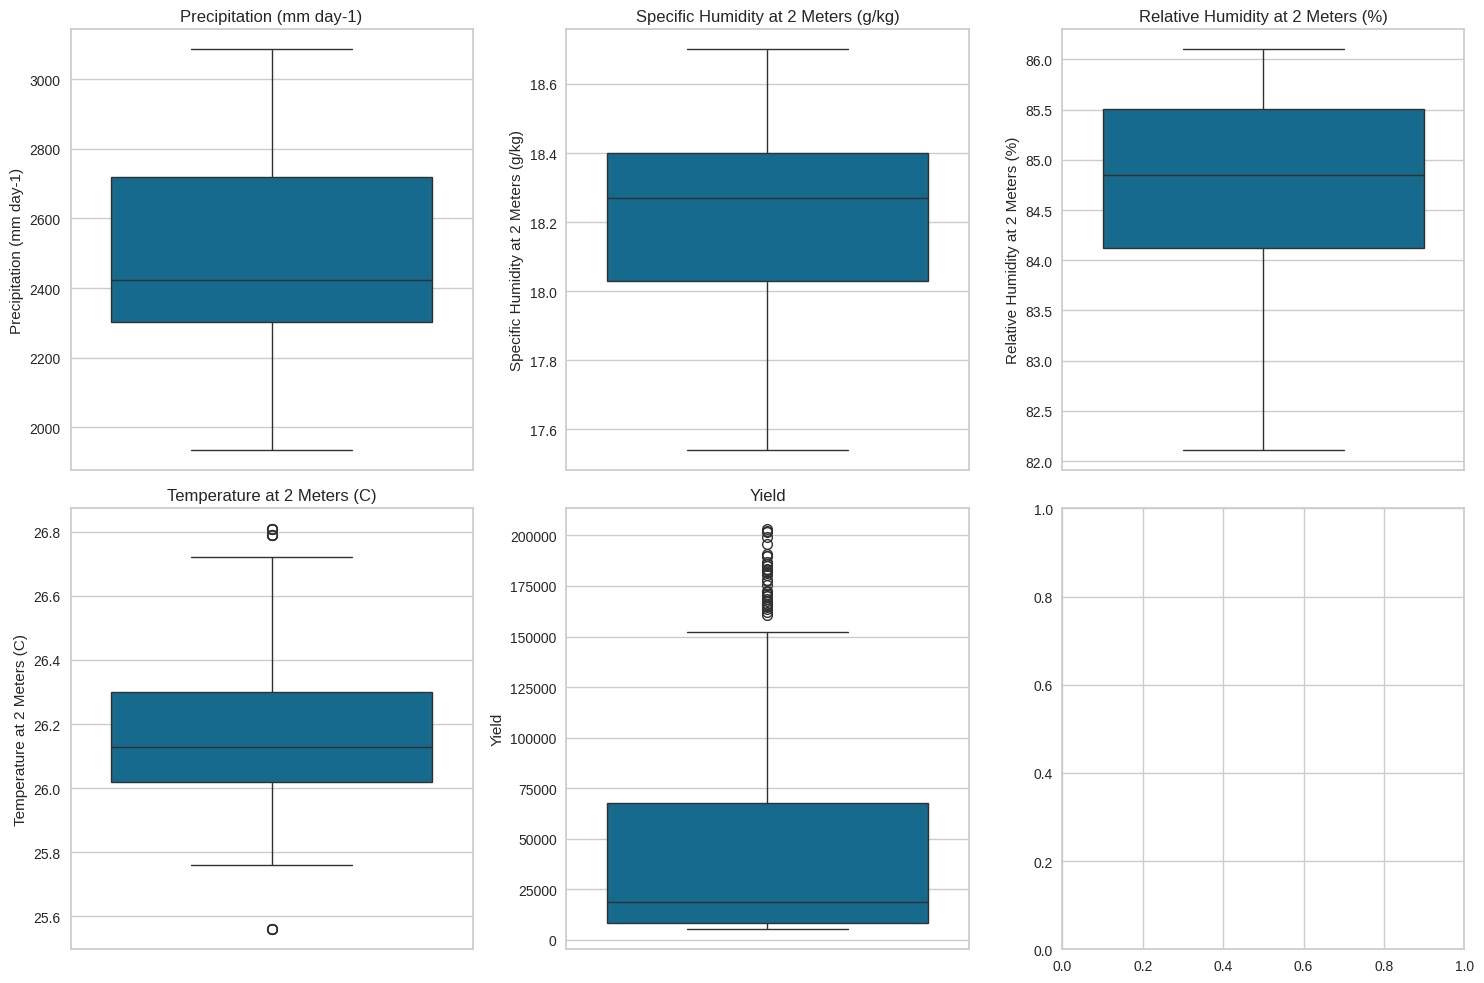

In [6]:
#VERIFICANDO OUTLIERS
#   - Selecionar as variáveis para o boxplot
features = ['Precipitation (mm day-1)',	'Specific Humidity at 2 Meters (g/kg)', 'Relative Humidity at 2 Meters (%)',	'Temperature at 2 Meters (C)',	'Yield']
#   - Criar uma figura com 2 linhas e 4 colunas
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
#   - Iterar pelas variáveis e criar o boxplot em cada subplot
for i, feature in enumerate(features):
    row = i // 3
    col = i % 3
    sns.boxplot(y=data[feature], ax=axes[row, col])
    axes[row, col].set_title(feature)
#   - Ajustar o layout da figura
plt.tight_layout()
plt.show()

Apesar de possuir outliers na feature 'Yield' não iremos tratar pois é importante a precisam dos numeros desse caso e possuimos poucas linhas no dataset

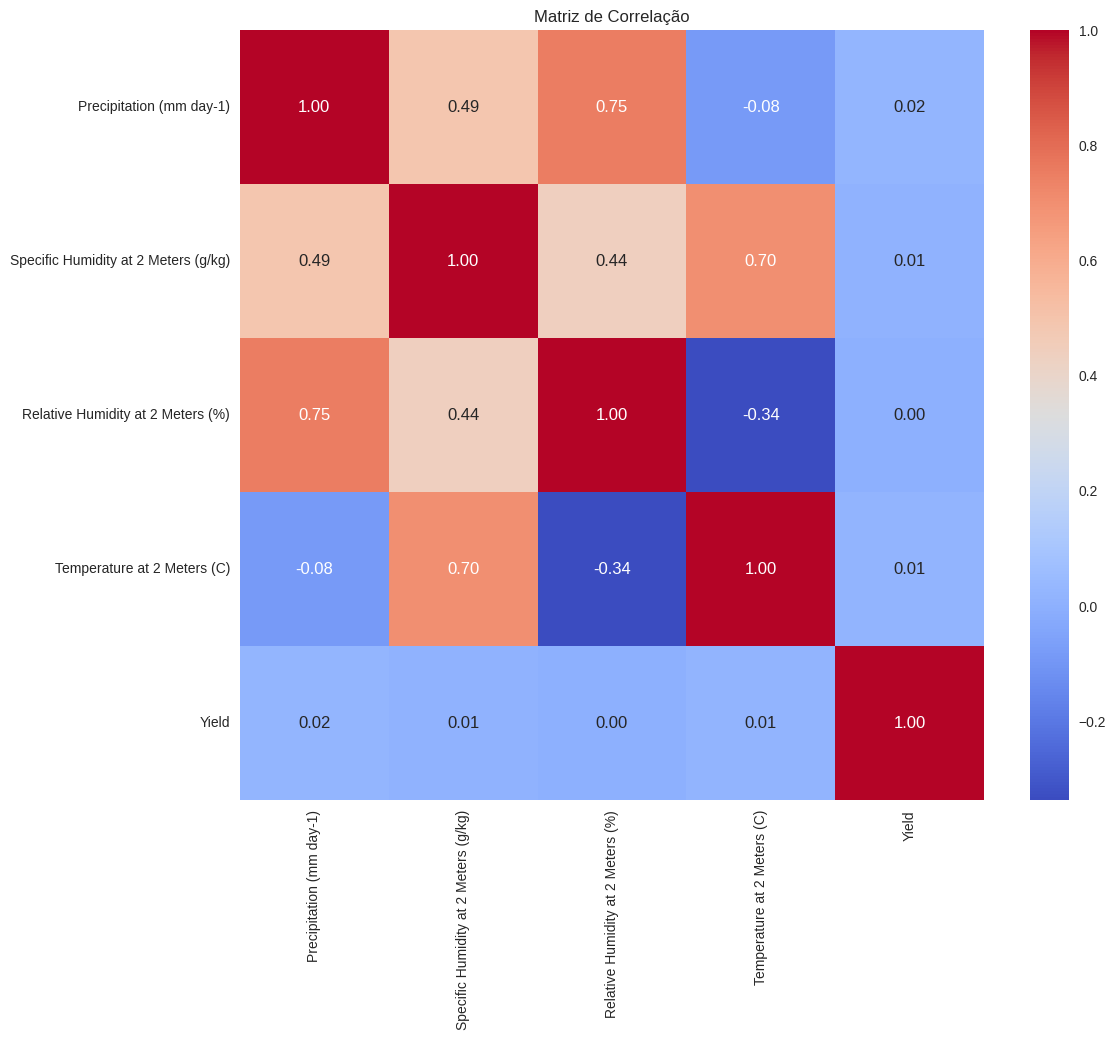

In [7]:
#CORRELAÇÃO ENTRE AS FEATURES
# Plot da matriz de correlação com mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

In [8]:
#Removendo features que não tem grande impacto
data.drop(columns=['Relative Humidity at 2 Meters (%)'], inplace=True)

Como as features 'Specific Humidity at 2 Meters (g/kg)' e 'Relative Humidity at 2 Meters (%)'são diretamente relacionadas podemos escolher entre uma delas e desconsiderar a outra tendo em vista que não representa impacto no modelo e dessa forma tambem redusimos a quantidade total de dados para ele processar

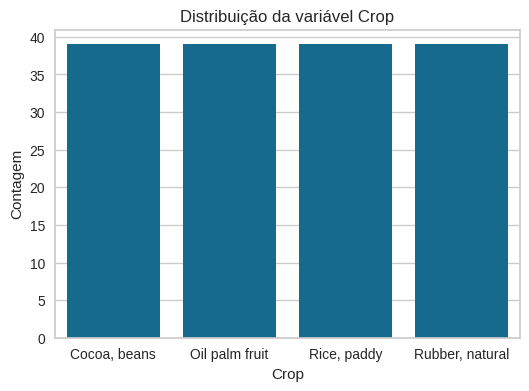

In [9]:
# Plotar o desbalanceamento da variável "Crop"
plt.figure(figsize=(6, 4))
sns.countplot(x='Crop', data=data)
plt.title('Distribuição da variável Crop')
plt.xlabel('Crop')
plt.ylabel('Contagem')
plt.show()

avaliando a quantidade de cada cultivo (Crop), avaliamos se exite desbalanceamento consideravel entre eles , como os graficos anteriores podem mostrar , todos tem a mesma quantidade de dados

##CLASSIFICAÇÃO(CLUSTERIZAÇÃO) ATRAVÈS DE VARIOS MODELOS DIFERENTES

In [10]:

# Inicializando o encoder
le = LabelEncoder()

# Aplicando e criando uma nova coluna
data['crop_encoded'] = le.fit_transform(data['Crop'])



Aqui transformamos a feature 'Crop' em numeral atraves do encoded para melhor desempenho do modelo

In [11]:
data = data.drop(columns=['Crop'])

In [12]:
data

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Temperature at 2 Meters (C),Yield,crop_encoded
0,2248.92,17.72,26.01,11560,0
1,1938.42,17.54,26.11,11253,0
2,2301.54,17.81,26.24,9456,0
3,2592.35,17.61,25.56,9321,0
4,2344.72,17.61,25.76,8800,0
...,...,...,...,...,...
151,2308.51,18.27,26.47,6721,3
152,2410.13,18.58,26.81,6248,3
153,2967.41,18.67,26.46,6842,3
154,2333.46,18.50,26.43,5571,3


In [13]:
# Separando os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(data.drop('crop_encoded', axis= 1),
                 data['crop_encoded'],
                 test_size=0.2,
                 random_state=42)
# Padronizando as features
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

Foi separado os dados em treino e teste sendo 80% de treino e 20% de teste, após isso foi padronizado atraves do StandardScaler para melhor adequação dos modelos

In [14]:
#FUNÇÕES PARA AVALIAR OS MODELOS
# Avaliando os modelos de classificação, calculando algumas métricas
def avaliar_modelo(y_true, y_pred, average):
    # Acurácia NÃO recebe o parâmetro average
    accuracy = accuracy_score(y_true, y_pred)

    # As outras métricas PRECISAM do average para multiclasse
    precision = precision_score(y_true, y_pred, average=average)
    recall = recall_score(y_true, y_pred, average=average)
    f1 = f1_score(y_true, y_pred, average=average)

    return accuracy, precision, recall, f1
# Plota a matriz de confusão
def plotar_matriz_confusao(y_true, y_pred, title):

    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)
    # Plot da matriz de confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[0, 1,2,3],
                yticklabels=[0, 1,2,3])
    plt.xlabel('Predição')
    plt.ylabel('Valor Real')
    plt.title(title)
    plt.show()


In [15]:
# Bagging - Combinação de 100 árvores independentes
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(),
                                  n_estimators=100,
                                  random_state=42)
bagging_model.fit(X_train_scaled, y_train)
y_pred_bagging = bagging_model.predict(X_test_scaled)
# Boosting
boosting_model = AdaBoostClassifier(n_estimators=100,
                                    random_state=42)
boosting_model.fit(X_train_scaled, y_train)
y_pred_boosting = boosting_model.predict(X_test_scaled)
# Definindo modelos base para ensembles para VOTING e STACKING
base_models = [
      ('dt', DecisionTreeClassifier(random_state=42)),
      ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
      ('knn', KNeighborsClassifier()),
      ('svm', SVC())
]
# Voting - Votação entre os modelos de base
voting_model = VotingClassifier(estimators=base_models,
                                voting='hard')
voting_model.fit(X_train_scaled, y_train)
y_pred_voting = voting_model.predict(X_test_scaled)
# Stacking
stacking_model = StackingClassifier(estimators=base_models,
                                    final_estimator=LogisticRegression())
stacking_model.fit(X_train_scaled, y_train)
y_pred_stacking = stacking_model.predict(X_test_scaled)
# XGBoost
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
# Avaliação dos modelos
accuracy_bagging, precision_bagging, recall_bagging, f1_bagging = avaliar_modelo(y_test, y_pred_bagging, average ='micro')
accuracy_boosting, precision_boosting, recall_boosting, f1_boosting = avaliar_modelo(y_test, y_pred_boosting, average ='micro')
accuracy_voting, precision_voting, recall_voting, f1_voting = avaliar_modelo(y_test, y_pred_voting, average ='micro')
accuracy_stacking, precision_stacking, recall_stacking, f1_stacking = avaliar_modelo(y_test, y_pred_stacking, average ='micro')
accuracy_xgb, precision_xgb, recall_xgb, f1_xgb = avaliar_modelo(y_test, y_pred_xgb,average ='micro' )
print(f"Bagging:	 \tAcurácia: {accuracy_bagging:.4f},         Precisão: {precision_bagging:.4f},         Recall: {recall_bagging:.4f},         F1-Score: {f1_bagging:.4f}")
print(f"Boosting:	 \tAcurácia: {accuracy_boosting:.4f},         Precisão: {precision_boosting:.4f},         Recall: {recall_boosting:.4f},         F1-Score: {f1_boosting:.4f}")
print(f"Voting:	   \tAcurácia: {accuracy_voting:.4f},         Precisão: {precision_voting:.4f},         Recall: {recall_voting:.4f},         F1-Score: {f1_voting:.4f}")
print(f"Stacking:	 \tAcurácia: {accuracy_stacking:.4f},         Precisão: {precision_stacking:.4f},         Recall: {recall_stacking:.4f},         F1-Score: {f1_stacking:.4f}")
print(f"XGBoost:	 \tAcurácia: {accuracy_xgb:.4f},         Precisão: {precision_xgb:.4f},         Recall: {recall_xgb:.4f},         F1-Score: {f1_xgb:.4f}")

Bagging:	 	Acurácia: 0.6875,         Precisão: 0.6875,         Recall: 0.6875,         F1-Score: 0.6875
Boosting:	 	Acurácia: 0.8438,         Precisão: 0.8438,         Recall: 0.8438,         F1-Score: 0.8438
Voting:	   	Acurácia: 0.6250,         Precisão: 0.6250,         Recall: 0.6250,         F1-Score: 0.6250
Stacking:	 	Acurácia: 0.9375,         Precisão: 0.9375,         Recall: 0.9375,         F1-Score: 0.9375
XGBoost:	 	Acurácia: 0.6875,         Precisão: 0.6875,         Recall: 0.6875,         F1-Score: 0.6875


Aqui conseguimos observar que entre os modelos Bagging, Boosting, Voting, Stacking e XGBoost o modelo que apresentou melhor resultado na classificação foi o Stacking com parametros acima de 0.93

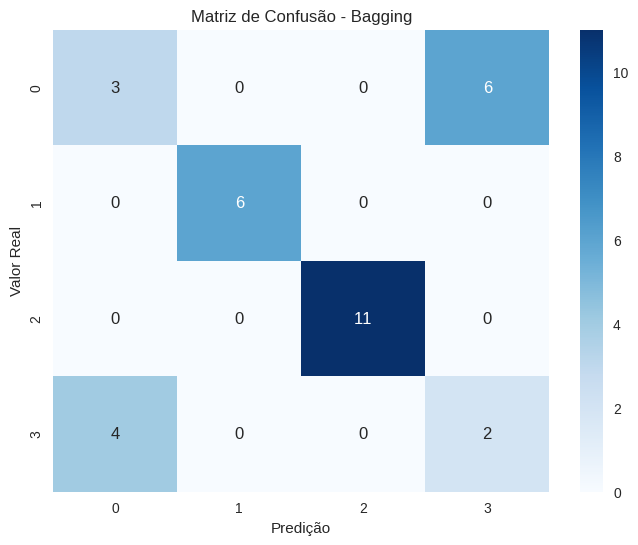

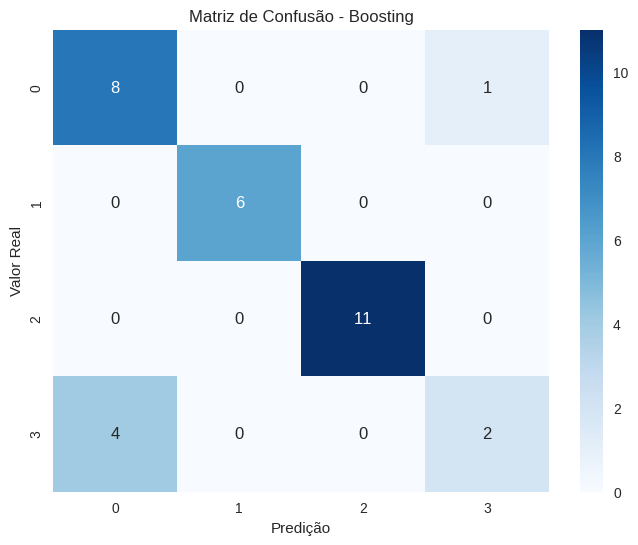

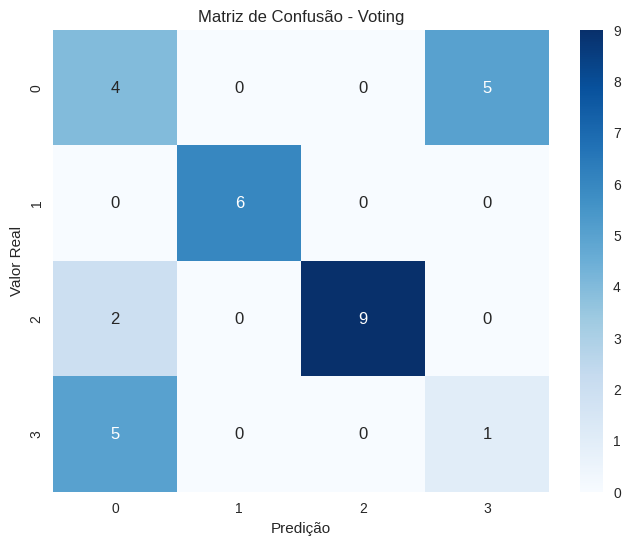

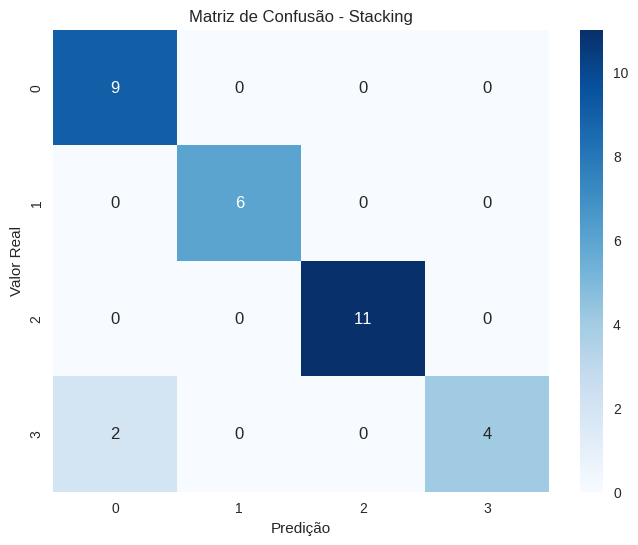

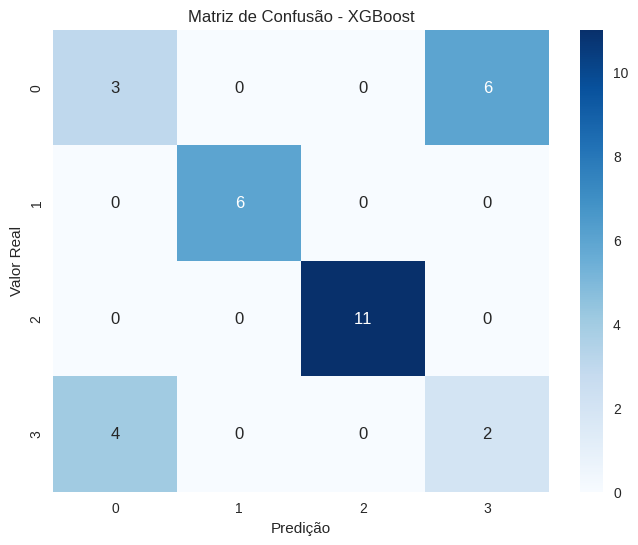

In [16]:
# Plota as matrizes de confusão para cada modelo

plotar_matriz_confusao(y_test, y_pred_bagging, "Matriz de Confusão - Bagging")
plotar_matriz_confusao(y_test, y_pred_boosting, "Matriz de Confusão - Boosting")
plotar_matriz_confusao(y_test, y_pred_voting, "Matriz de Confusão - Voting")
plotar_matriz_confusao(y_test, y_pred_stacking, "Matriz de Confusão - Stacking")
plotar_matriz_confusao(y_test, y_pred_xgb, "Matriz de Confusão - XGBoost")

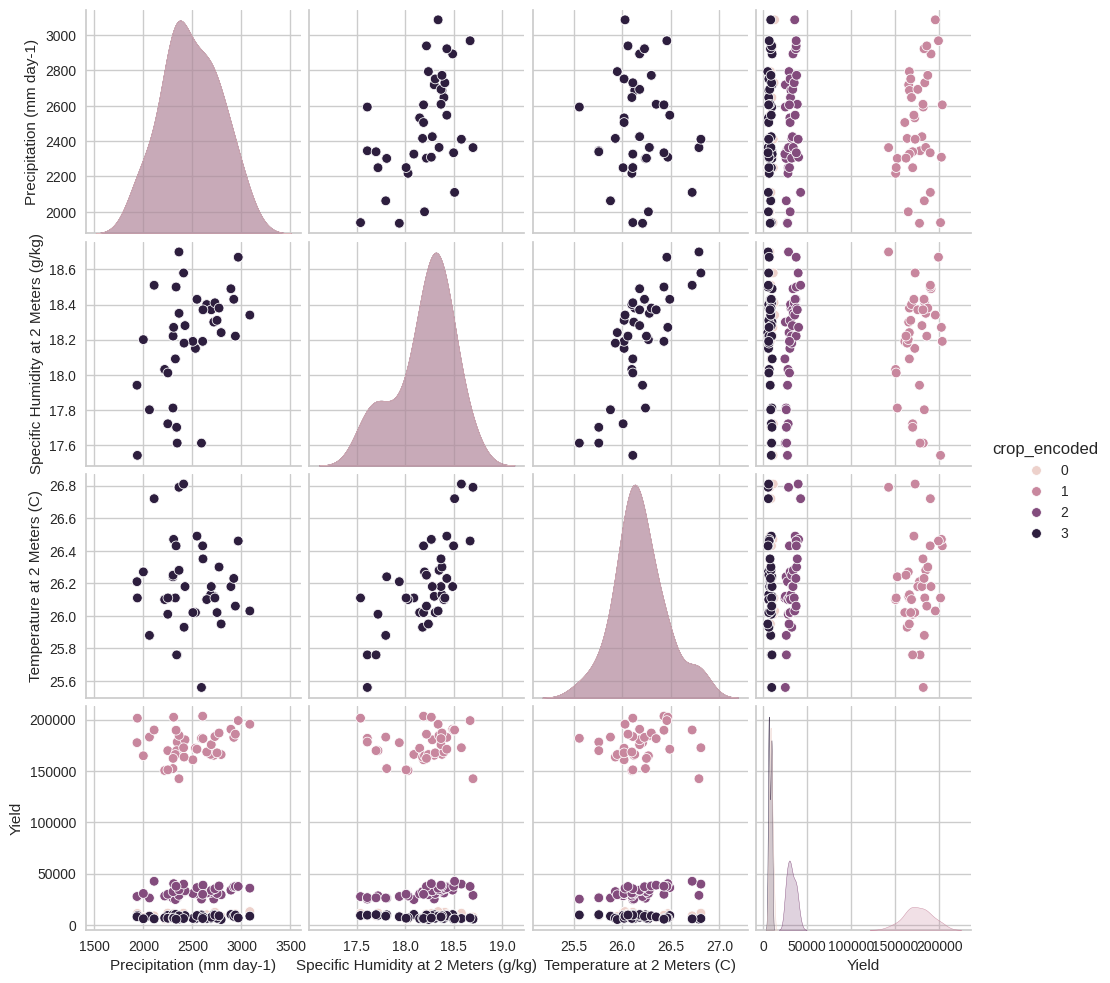

In [17]:
sns.pairplot(data=data, vars =('Precipitation (mm day-1)',	'Specific Humidity at 2 Meters (g/kg)',	'Temperature at 2 Meters (C)',	'Yield'),              hue='crop_encoded' );

In [18]:

mapeamento = dict(zip(le.classes_, range(len(le.classes_))))
print(mapeamento)


{'Cocoa, beans': 0, 'Oil palm fruit': 1, 'Rice, paddy': 2, 'Rubber, natural': 3}


Atraves do modelo de matris de confusão e da ferramenta do seaborn pairplot podemos observar que existem duas classes que são mais facilmente confundidas pelos modelos classes '0' e '3'

In [19]:
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

##Perceptron e MLPerceptron

Agora utilizaremos o modelo de um ou mais neuronios para a classificação do modelo e avaliaremos seus resultados

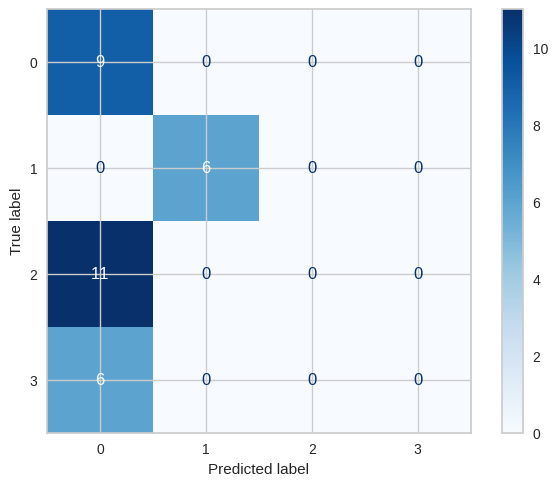

In [20]:
# Cria um perceptron e o treina (com o fit())
p = Perceptron( random_state=42 )
p.fit(X_train, y_train)
# Salva as predições do TESTE na variável y_pred
y_pred = p.predict(X_test)
# Matriz de confusão do perceptron
from sklearn.metrics import confusion_matrix
def matriz_confusao(teste_labels, teste_preds, labels):
  cm = confusion_matrix(teste_labels, teste_preds, labels=labels)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=labels)
  disp.plot(cmap="Blues")
matriz_confusao(y_test, y_pred, p.classes_)

ACC Teste:  0.6875


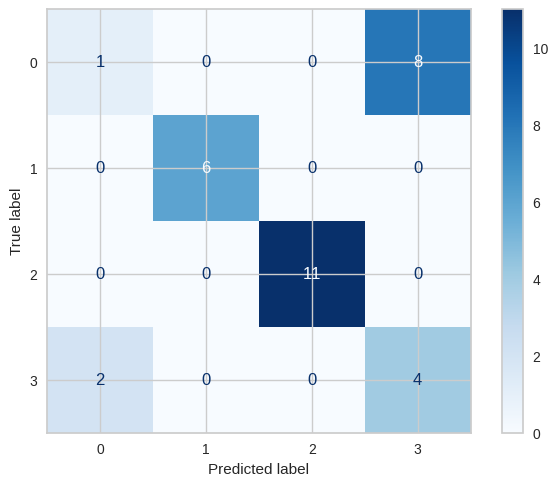

In [21]:
#Arquitetura
mlp = MLPClassifier(
    hidden_layer_sizes=(10,8,),
    solver='lbfgs',
    alpha=1e-2,
    verbose=True,
    max_iter=100,
    random_state=42
)
# Treinamento
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)
# Avaliação
matriz_confusao(y_test, y_pred, mlp.classes_)
print("ACC Teste: ", accuracy_score(y_test, y_pred))

ACC Teste:  0.71875


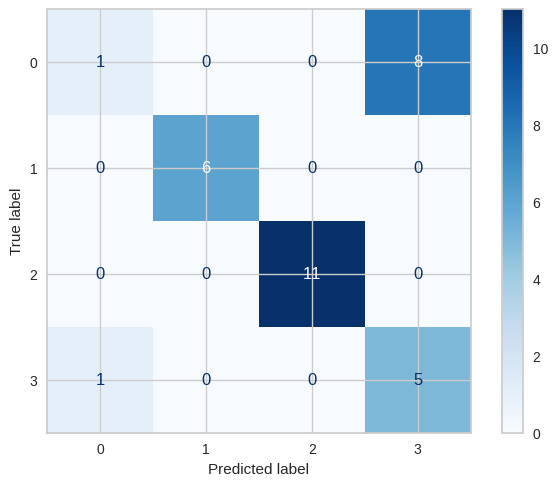

In [22]:
mlp = MLPClassifier(
    hidden_layer_sizes=(20,10,),
    verbose=False,
    max_iter=80,
    random_state=42,
    activation="logistic",
    solver="lbfgs"
)
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)
print("ACC Teste: ", accuracy_score(y_test, y_pred))
matriz_confusao(y_test, y_pred, mlp.classes_)

É possivel observar que utilizando o MLPerceptron na ativação 'logistic' o resultado foi relativamente melhor que o sua ativação default e que o Perceptron.
Através de testes os parametros ajustados conseguiram uma acuracia de 0.718   

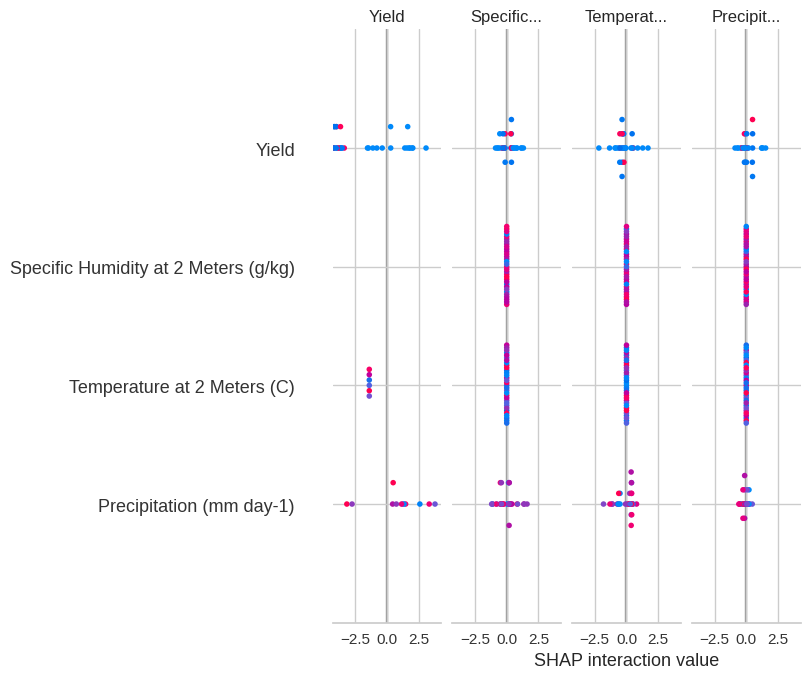

In [23]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X_test.columns.tolist())

In [24]:
import lime
import lime.lime_tabular

# 1. Criar o explicador
# training_data deve ser o seu X_train_scaled (em formato numpy)
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X_test.columns.tolist(),
    class_names=mlp.classes_.tolist(), # ou xgb_model.classes_
    mode='classification' # ou 'regression'
)

# 2. Escolher um exemplo específico do teste para explicar (ex: o primeiro da lista)
i = 0

# 3. Gerar a explicação
# O LIME precisa de uma função que receba os dados e retorne probabilidades
exp = explainer.explain_instance(
    data_row=X_test_scaled[i],
    predict_fn=xgb_model.predict_proba # Use o seu modelo aqui
)

# 4. Mostrar o resultado
exp.show_in_notebook(show_table=True)

Atraves dos metodos Shap e Lime podemos ver a importancia das varaiveis no resultado final e observar que a classificação é paltada principalmente na variavel Yield

##PREDIÇÃO DE YIELD

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
from pycaret.regression import *
train_two,test = train_test_split( data_predict.drop(['crop_encoded'], axis = 1), test_size=0.2, random_state=42)

reg = setup(
    data = train_two,
    target = 'Yield',     # O PyCaret já vai TIRAR o Yield das entradas aqui
    session_id = 42,
    preprocess = True
)

# 3. VERIFICAÇÃO DEFINITIVA
# Rode isso para ver se o Yield sumiu das entradas:
cols_entrada = get_config('X_train').columns
print("Variáveis que o modelo vai usar:", cols_entrada)

if 'Yield' in cols_entrada:
    print("ERRO: O Yield ainda está lá!")
else:
    print("SUCESSO: O Yield foi removido das entradas e é apenas o Target.")

,Description,Value
0,Session id,42
1,Target,Yield
2,Target type,Regression
3,Original data shape,"(124, 5)"
4,Transformed data shape,"(124, 8)"
5,Transformed train set shape,"(86, 8)"
6,Transformed test set shape,"(38, 8)"
7,Numeric features,3
8,Categorical features,1
9,Preprocess,True


Variáveis que o modelo vai usar: Index(['Crop', 'Precipitation (mm day-1)',
       'Specific Humidity at 2 Meters (g/kg)', 'Temperature at 2 Meters (C)'],
      dtype='object')
SUCESSO: O Yield foi removido das entradas e é apenas o Target.


Foi treinado varios modelos de predição para identificar o melhor

In [27]:
compare_models(sort="R2")

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,4447.6605,57587575.8370,7000.0673,0.9885,0.1551,0.1224,0.2440
rf,Random Forest Regressor,4441.5718,61729326.6035,7160.1035,0.9880,0.1608,0.1271,0.6850
lr,Linear Regression,4873.8288,55446728.0266,7105.3244,0.9871,0.2397,0.1856,1.5370
lasso,Lasso Regression,4869.8111,55373969.9195,7101.5679,0.9871,0.2394,0.1854,0.1200
lar,Least Angle Regression,4848.7313,55514171.5790,7109.7247,0.9871,0.2352,0.1818,0.0880
llar,Lasso Least Angle Regression,4869.8639,55372570.8426,7101.5435,0.9871,0.2394,0.1854,0.1110
ridge,Ridge Regression,5390.0411,66239242.4735,7649.6671,0.9858,0.2827,0.2531,0.1720
ada,AdaBoost Regressor,4863.3854,72976486.7887,7608.7087,0.9855,0.1811,0.1520,0.1820
gbr,Gradient Boosting Regressor,5060.8324,82719525.5370,8200.8377,0.9839,0.1649,0.1337,0.1670
dt,Decision Tree Regressor,5432.7764,86355958.8347,8229.3224,0.9833,0.2037,0.1549,0.0760


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

ExtraTreesRegressor(n_jobs=-1, random_state=42)

Comparando o desempenho dos modelos treinados o modelo de Extra Trees Regressor apresentou melhores resultados de predição

In [28]:
et = create_model("et")

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2684.8589,18722970.3554,4327.0048,0.9937,0.1284,0.1132
1,6254.7844,114740975.1726,10711.7214,0.9784,0.1598,0.1184
2,2609.1767,12320521.5214,3510.0600,0.9947,0.1963,0.1568
3,6559.5478,83043367.4588,9112.8134,0.9871,0.1599,0.1352
4,5917.6667,102514637.3982,10124.9512,0.9836,0.1588,0.1263
5,2601.1056,18413543.4048,4291.1005,0.9906,0.1898,0.1575
6,3198.5400,21186578.6005,4602.8881,0.9929,0.1313,0.1148
7,4059.4625,38586846.3962,6211.8312,0.9934,0.1850,0.1099
8,6734.2075,137273420.9140,11716.3741,0.9771,0.0832,0.0678


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Treinado o modelo de Extra Trees Regressor obtivemos bons resultados como mostrado na celula executada acima

In [29]:
tuned_et = tune_model(et)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2820.8811,19209917.5126,4382.9120,0.9935,0.1743,0.1363
1,5666.0274,86814144.6467,9317.4108,0.9836,0.1720,0.1291
2,3377.3055,20201194.9581,4494.5739,0.9913,0.2253,0.2004
3,5736.2712,55804747.9478,7470.2576,0.9913,0.1419,0.1371
4,4710.4298,53529840.7619,7316.4090,0.9915,0.1666,0.1349
5,3375.9796,44787071.9535,6692.3144,0.9772,0.1327,0.1145
6,3388.0267,18764616.2314,4331.8144,0.9937,0.1559,0.1400
7,4407.6773,62235635.2793,7888.9565,0.9894,0.1705,0.1353
8,6988.2352,143203657.5512,11966.7731,0.9761,0.1170,0.0982


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


após a tentativa de melhorar o modelo atraves do tuned é possivel notar que o modelo não obteve melhora significativa no desempenho que o original

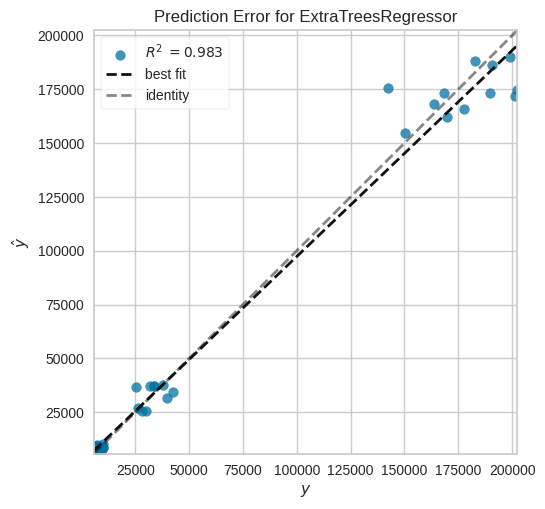

In [30]:
plot_model(et, plot = "error")

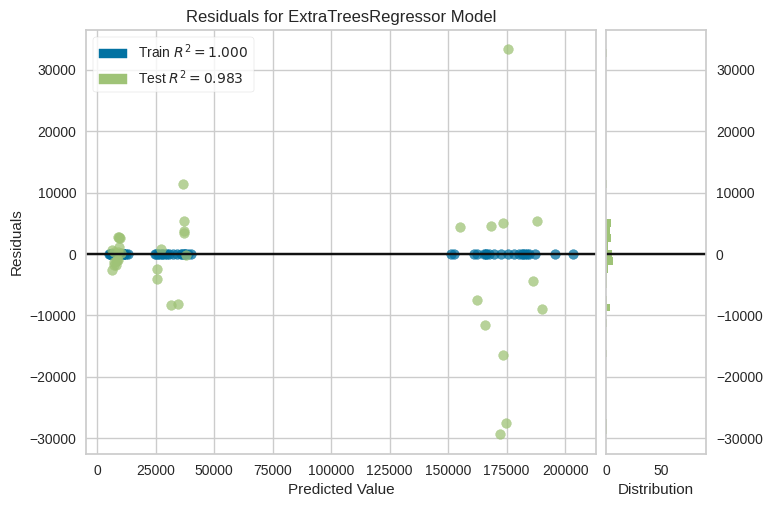

In [31]:
##comparar residuos
plot_model(et, plot = "residuals")

Conseguimos analisar o erro cometido pelo modelo e observamos que o r2 está proximo de 0.99

In [32]:
predict_model(et, data=test)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,3201.0844,23004059.6366,4796.2548,0.9941,0.1189,0.0987


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Temperature at 2 Meters (C),Yield,prediction_label
96,"Rice, paddy",2792.949951,18.240000,25.950001,29415,36413.31
69,Oil palm fruit,2938.290039,18.219999,26.059999,185831,179964.32
82,"Rice, paddy",2344.719971,17.610001,25.760000,26648,26156.68
76,Oil palm fruit,2333.459961,18.500000,26.430000,189657,178595.47
114,"Rice, paddy",2967.409912,18.670000,26.459999,37496,34200.80
29,"Cocoa, beans",2546.330078,18.430000,26.490000,7795,9226.93
94,"Rice, paddy",1999.530029,18.200001,26.270000,30676,30839.12
132,"Rubber, natural",2414.790039,18.180000,25.930000,6562,6093.76
93,"Rice, paddy",2414.790039,18.180000,25.930000,32510,29906.29
139,"Rubber, natural",2692.340088,18.370001,26.180000,7435,9079.68


Testando o modelo e fazendo predições obtemos 0.0.9941 de R2

In [33]:
et_modelo_final = finalize_model(et)

Criamos o modelo final para produção

In [34]:
save_model(et_modelo_final, "modelo_et_predict")

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['Precipitation (mm day-1)',
                                              'Specific Humidity at 2 Meters '
                                              '(g/kg)',
                                              'Temperature at 2 Meters (C)'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['Crop'],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('onehot_encoding',
                  TransformerWrapper(include=['Crop'],
                                     transformer=OneHotEncoder(cols=['Crop'],
                                                               handle_missing='return_nan',
                                                               use_cat_names=True))),
                 ('clean_colum

Salvamos em um arquivo .pkl para utilizar em outras ocaziões

#Modelo de Random Forest Regressor

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2251.4667,7975518.9346,2824.0961,0.9973,0.1668,0.1344
1,6223.3467,119892003.8256,10949.5207,0.9774,0.1613,0.1179
2,2594.4067,12120979.5979,3481.5197,0.9948,0.2133,0.1694
3,6169.3633,92208783.9627,9602.5405,0.9857,0.1403,0.1312
4,5787.4722,110464918.0474,10510.2292,0.9824,0.1536,0.1293
5,2225.1189,16138798.4154,4017.3123,0.9918,0.1511,0.1236
6,3304.2325,27395316.9630,5234.0536,0.9908,0.1189,0.0966
7,4220.4800,60721799.5042,7792.4194,0.9897,0.1793,0.1010
8,7704.7963,143019403.7066,11959.0720,0.9762,0.1188,0.1053


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

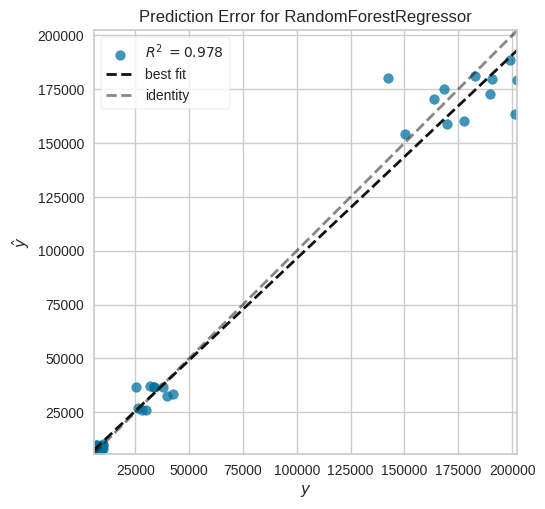

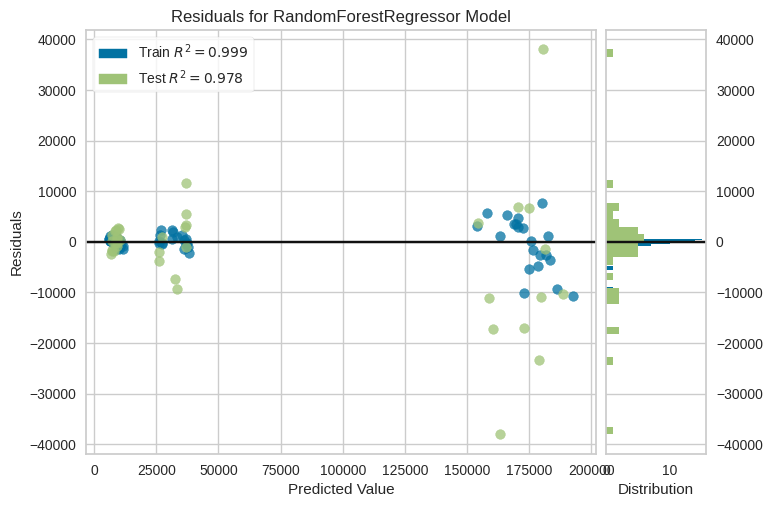

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,2912.6891,20285146.8763,4503.9035,0.9948,0.1113,0.0880


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Temperature at 2 Meters (C),Yield,prediction_label
96,"Rice, paddy",2792.949951,18.240000,25.950001,29415,36121.28
69,Oil palm fruit,2938.290039,18.219999,26.059999,185831,174596.84
82,"Rice, paddy",2344.719971,17.610001,25.760000,26648,26120.10
76,Oil palm fruit,2333.459961,18.500000,26.430000,189657,181537.33
114,"Rice, paddy",2967.409912,18.670000,26.459999,37496,35469.99
29,"Cocoa, beans",2546.330078,18.430000,26.490000,7795,8937.90
94,"Rice, paddy",1999.530029,18.200001,26.270000,30676,30424.56
132,"Rubber, natural",2414.790039,18.180000,25.930000,6562,6251.63
93,"Rice, paddy",2414.790039,18.180000,25.930000,32510,30211.10
139,"Rubber, natural",2692.340088,18.370001,26.180000,7435,8669.28


In [35]:
rf = create_model("rf")
plot_model(rf, plot = "error")
plot_model(rf, plot = "residuals")
predict_model(rf, data=test)

#Modelo de Lasso Least Angle Regression

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2813.8519,19552642.6764,4421.8370,0.9934,0.1764,0.1467
1,5482.6719,67341920.2949,8206.2123,0.9873,0.1466,0.1333
2,3155.9221,21962842.1481,4686.4530,0.9906,0.1882,0.1456
3,6168.6278,58410024.2898,7642.6451,0.9909,0.2337,0.2087
4,5955.7355,52663045.8363,7256.9309,0.9916,0.2973,0.2662
5,4192.8068,63337884.0921,7958.5102,0.9678,0.2084,0.1768
6,4302.6015,21102774.3328,4593.7756,0.9929,0.4264,0.2552
7,5325.1953,89660833.4355,9468.9405,0.9848,0.2944,0.1869
8,7158.6306,131440452.5490,11464.7483,0.9781,0.1707,0.1352


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

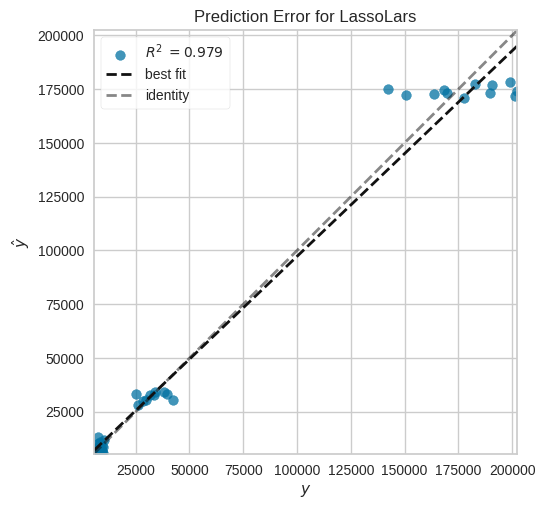

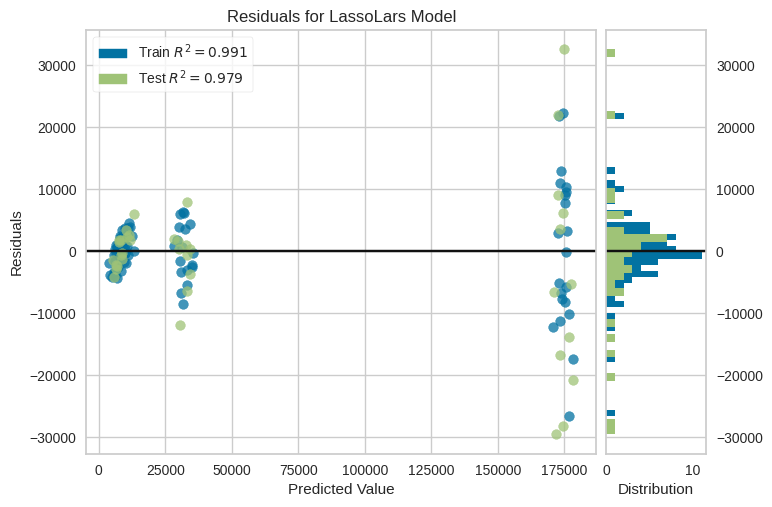

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Least Angle Regression,3140.2172,18654687.7466,4319.1073,0.9952,0.2189,0.1532


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Temperature at 2 Meters (C),Yield,prediction_label
96,"Rice, paddy",2792.949951,18.240000,25.950001,29415,33091.935530
69,Oil palm fruit,2938.290039,18.219999,26.059999,185831,177456.261297
82,"Rice, paddy",2344.719971,17.610001,25.760000,26648,30619.770210
76,Oil palm fruit,2333.459961,18.500000,26.430000,189657,173469.328961
114,"Rice, paddy",2967.409912,18.670000,26.459999,37496,35741.101089
29,"Cocoa, beans",2546.330078,18.430000,26.490000,7795,10882.610804
94,"Rice, paddy",1999.530029,18.200001,26.270000,30676,28421.118331
132,"Rubber, natural",2414.790039,18.180000,25.930000,6562,5722.938272
93,"Rice, paddy",2414.790039,18.180000,25.930000,32510,30083.891967
139,"Rubber, natural",2692.340088,18.370001,26.180000,7435,8676.680573


In [36]:
llar = create_model("llar")
plot_model(llar, plot = "error")
plot_model(llar, plot = "residuals")
predict_model(llar, data=test)

#Modelo de Least Angle Regression

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2813.8519,19552642.6764,4421.8370,0.9934,0.1764,0.1467
1,5482.6719,67341920.2949,8206.2123,0.9873,0.1466,0.1333
2,3155.9221,21962842.1481,4686.4530,0.9906,0.1882,0.1456
3,6168.6278,58410024.2898,7642.6451,0.9909,0.2337,0.2087
4,5955.7355,52663045.8363,7256.9309,0.9916,0.2973,0.2662
5,4192.8068,63337884.0921,7958.5102,0.9678,0.2084,0.1768
6,4302.6015,21102774.3328,4593.7756,0.9929,0.4264,0.2552
7,5325.1953,89660833.4355,9468.9405,0.9848,0.2944,0.1869
8,7158.6306,131440452.5490,11464.7483,0.9781,0.1707,0.1352


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

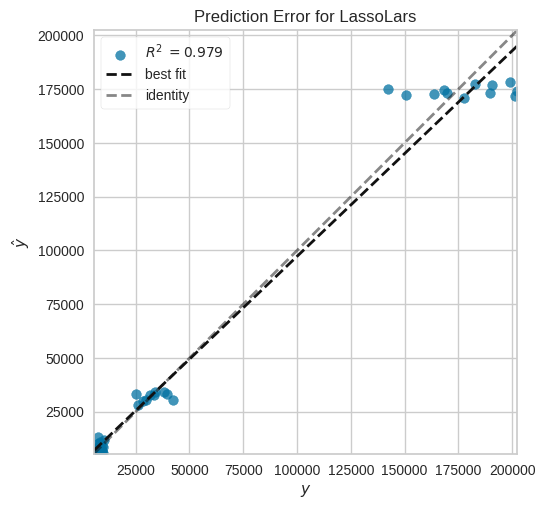

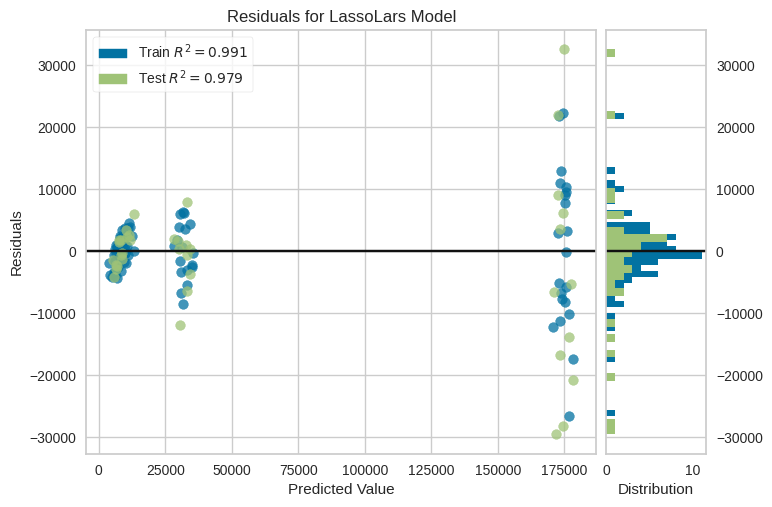

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Least Angle Regression,3140.2172,18654687.7466,4319.1073,0.9952,0.2189,0.1532


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Temperature at 2 Meters (C),Yield,prediction_label
96,"Rice, paddy",2792.949951,18.240000,25.950001,29415,33091.935530
69,Oil palm fruit,2938.290039,18.219999,26.059999,185831,177456.261297
82,"Rice, paddy",2344.719971,17.610001,25.760000,26648,30619.770210
76,Oil palm fruit,2333.459961,18.500000,26.430000,189657,173469.328961
114,"Rice, paddy",2967.409912,18.670000,26.459999,37496,35741.101089
29,"Cocoa, beans",2546.330078,18.430000,26.490000,7795,10882.610804
94,"Rice, paddy",1999.530029,18.200001,26.270000,30676,28421.118331
132,"Rubber, natural",2414.790039,18.180000,25.930000,6562,5722.938272
93,"Rice, paddy",2414.790039,18.180000,25.930000,32510,30083.891967
139,"Rubber, natural",2692.340088,18.370001,26.180000,7435,8676.680573


In [37]:
llar = create_model("llar")
plot_model(llar, plot = "error")
plot_model(llar, plot = "residuals")
predict_model(llar, data=test)

#Modelo de Gradient Boosting Regressor

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2464.3095,15880282.1173,3985.0072,0.9946,0.1374,0.1105
1,6208.1665,123194567.6228,11099.3048,0.9768,0.1786,0.1255
2,3468.1244,29561132.7740,5437.0151,0.9873,0.2075,0.1766
3,8117.5229,174663622.1483,13216.0366,0.9728,0.1279,0.1109
4,5660.6161,123713300.4198,11122.6481,0.9803,0.1463,0.1283
5,2831.3172,16551881.1508,4068.4003,0.9916,0.2481,0.2159
6,3584.0679,34195049.8389,5847.6534,0.9886,0.1040,0.0928
7,4861.1009,65804335.5038,8111.9871,0.9888,0.2019,0.1114
8,10245.4301,227270402.8588,15075.4901,0.9621,0.1337,0.1330


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

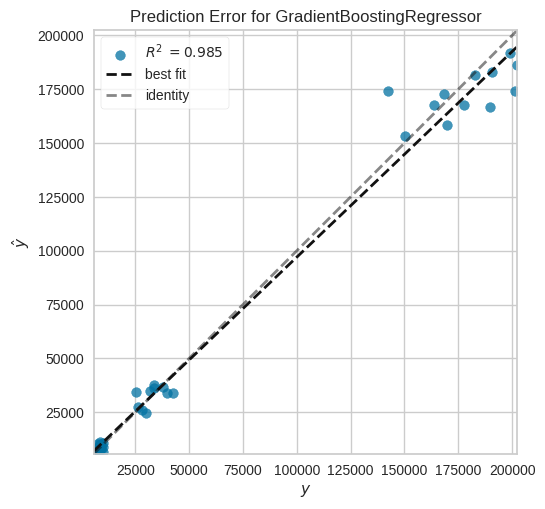

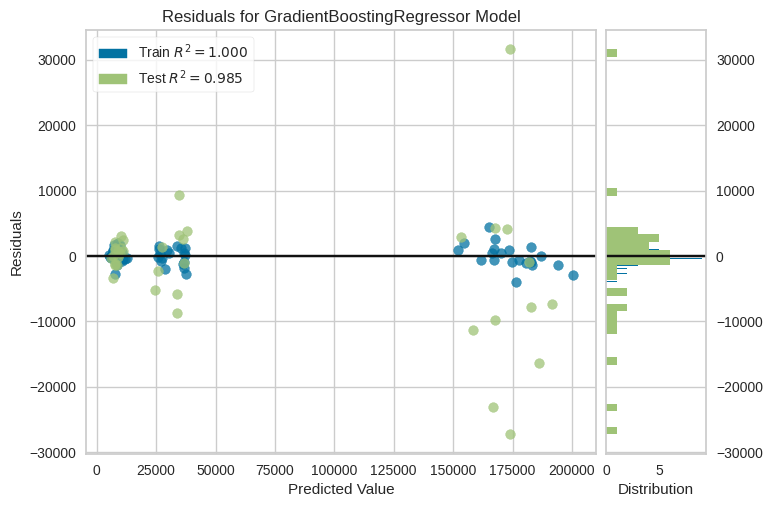

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,3966.4273,46130159.6874,6791.9187,0.9881,0.1166,0.0962


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Temperature at 2 Meters (C),Yield,prediction_label
96,"Rice, paddy",2792.949951,18.240000,25.950001,29415,32787.781762
69,Oil palm fruit,2938.290039,18.219999,26.059999,185831,172115.061679
82,"Rice, paddy",2344.719971,17.610001,25.760000,26648,26595.031169
76,Oil palm fruit,2333.459961,18.500000,26.430000,189657,167036.956900
114,"Rice, paddy",2967.409912,18.670000,26.459999,37496,32652.083946
29,"Cocoa, beans",2546.330078,18.430000,26.490000,7795,9786.129960
94,"Rice, paddy",1999.530029,18.200001,26.270000,30676,28785.751598
132,"Rubber, natural",2414.790039,18.180000,25.930000,6562,6085.269653
93,"Rice, paddy",2414.790039,18.180000,25.930000,32510,28745.113415
139,"Rubber, natural",2692.340088,18.370001,26.180000,7435,7508.692010


In [38]:
gbr = create_model("gbr")
plot_model(gbr, plot = "error")
plot_model(gbr, plot = "residuals")
predict_model(gbr, data=test)

##CONCLUSÃO

Através de técnicas de data Science constatamos que a base é solida sem dados faltantes ou duplicados , porem com poucos dados disponíveis.
A remoção de uma variável foi possível por sua alta correlação com outra não interferindo nos modelos de clusterização ou predição.
Aplicando técnicas de machine learn para realizar a clusterização conseguimos constatar que na fazenda em que os dados foram colhidos as variáveis não interferem tanto quando o tipo de plantio que foi cultivado, podemos observar que existem uma distribuição dos cultivos quase que uniforme mesmo com a variação dos parâmetros , ou seja o cultivo de Oil palm fruit tem uma produção consideravelmente maior por hectare que os demais cultivos.
O modelo de predição se comportou bem aos dados tendo uma boa performasse quando utilizado o modelo de Extra Trees Regressor , alcançando R2 proximo de 0.99 , foi o modelo indicado pela biblioteca Pycaret , porem foi treinado mais 4 modelos diferentes com ('rf', 'llar', 'lr', 'gbr') onde obtiveram resultados semelhantes

In [39]:
from pycaret.regression import load_model, predict_model
import pandas as pd

# 1. Carregar o modelo
modelo = load_model('modelo_et_predict')

# 2. Novos dados
dados_novos = pd.DataFrame([{
    'Crop':'Cocoa, beans',
    'Specific Humidity at 2 Meters (g/kg)': 19.21,
    'Temperature at 2 Meters (C)': 22.05,
    'Precipitation (mm day-1)': 20000,


}])

# 3. Fazer a predição
previsoes = predict_model(modelo, data=dados_novos)

# O resultado aparecerá em uma nova coluna chamada 'prediction_label'
print(previsoes)


Transformation Pipeline and Model Successfully Loaded


           Crop  Specific Humidity at 2 Meters (g/kg)  \
0  Cocoa, beans                             19.209999   

   Temperature at 2 Meters (C)  Precipitation (mm day-1)  prediction_label  
0                    22.049999                     20000          10807.16  


Teste de importação de modelo preditivo

In [40]:
#Previsao de produção para o terrono de 20 hectares
predicao = previsoes['prediction_label'].iloc[0]
producao_total = predicao * 200
print(f"A produção total caso seja plantado em todos os 200 hectares é de {producao_total} toneladas")

A produção total caso seja plantado em todos os 200 hectares é de 2161432.0 toneladas


##Modelo para predição de varios tipos de cultivo em varias condições de solo, de acordo com sua area plantada

In [41]:
colunas_predicao = ['Cultivo','Area_plantada','Producao_estimada']

data_set = pd.DataFrame(columns = colunas_predicao)

escolha = input("Deseja adicionar algum dado? S/N").upper()

while escolha == 'S':
  modelo = load_model('modelo_et_predict')

  area_plantada = float(input("Qual area será destinada ao plantio (hectares)?"))
  cultivo = input("Qual cultivo ?")
  humidade = input("Qual a humidade do solo a 2 Metros (g/kg)")
  temperatura = input("Qual a temperatura a 2 Metros (c)")
  precipitacao = input("Qual a precipitação ? (mm day-1)")

  dados_predic = pd.DataFrame([{
    'Crop': cultivo,
    'Specific Humidity at 2 Meters (g/kg)': humidade,
    'Temperature at 2 Meters (C)': temperatura,
    'Precipitation (mm day-1)': precipitacao,
  }])

  previsoes = predict_model(modelo, data=dados_predic)

  preducao_estimada = (previsoes['prediction_label'].iloc[0])*area_plantada

  dados_n = pd.DataFrame({
      'Cultivo':[cultivo],
      'Area_plantada': [area_plantada],
      'Producao_estimada': [preducao_estimada]

  })
  data_set = pd.concat([dados_n,data_set], ignore_index= True)

  escolha = input("Deseja adicionar mais algum dado? S/N").upper()

print(data_set)






KeyboardInterrupt: Interrupted by user